1. Import Libraries

In [ ]:
import tensorflow as tf  
from tensorflow import keras
from tensorflow.keras import layers,models
import matplotlib.pyplot as plt 
import numpy as np 

# TensorFlow is the deep-learning framework.

# Keras (inside TF) makes building neural networks easy.

# layers gives access to building blocks like Conv2D, Dense, Flatten, etc.

2. Load Dataset (MNIST Fashion)

In [ ]:
# A simple dataset of clothing images.
# a dataset of 60,000 small 32×32 color images in 10 categories (cat, dog, airplane…).

# It automatically splits into:

# x_train → training images

# y_train → training labels

# x_test → test images

# y_test → test labels 

from tensorflow.keras.datasets import fashion_mnist
(X_train,y_train),(X_test,y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


3. Preprocess Data

In [ ]:
# CNNs need images with a channel dimension
#  Normalize the Images: Pixel values are between 0 and 255.

# Dividing by 255 scales them to 0–1, making training more stable.
X_train= X_train/255.0
X_test= X_test/255.0

# Add channel dimension (28, 28, 1)
X_train=np.expand_dims(X_train,-1)
X_test= np.expand_dims(X_test,-1)

4. Build a Simple CNN Model

In [ ]:
# Layer 1: Convolution: Uses 32 filters (feature detectors)
# Each filter is 3×3
# Finds patterns like edges, lines, textures
# Activation ReLU keeps only positive values
# input_shape = (height, width, channels)
# It converts image → feature maps.

# Layer 2: Max Pooling 
# Reduces image size
# Helps model focus on important features
# Prevents overfitting
# (Think of it as “keeping only the strongest signal.”)

In [ ]:
model = models.Sequential([
layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)), # Second Convolution + Pooling -Learns more complex features like shapes, corners, small objects
layers.MaxPooling2D(2,2),

# Third Convolution :Extracts even higher-level visual patterns
# (e.g., eyes, wheels, textures)
layers.Conv2D(64, (3,3), activation='relu'),
layers.MaxPooling2D(2,2),


layers.Flatten(),                         #Flatten Layer :Converts 2D feature maps → single long vector.
layers.Dense(128, activation='relu'),    #Dense Layer (Hidden Layer):Learns combinations of features,(e.g., “2 wheels + wings → airplane”).
layers.Dense(10, activation='softmax')
])

# Output Layer :10 neurons = 10 classes,Softmax outputs probabilities that sum to 1

model.summary()

5. Compile the Model

In [ ]:
# adam → advanced optimizer that adapts learning
# sparse_categorical_crossentropy → for multi-class classification with integer labels
# accuracy → track accuracy during training

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

6. Train the Model

In [ ]:
# epochs=10 → the model sees the full dataset 10 times
# Learns to reduce loss
# Tracks accuracy on training + validation data

history= model.fit(X_train,y_train,epochs= 5,validation_split=0.1)

7. Evaluate on Test Set

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test accuracy:", test_acc)

8. Plot Training Results

In [ ]:
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.show()

9. Make Predictions

In [ ]:
pred = model.predict(X_test[:5])
print(np.argmax(pred, axis=1))
print(y_test[:5])

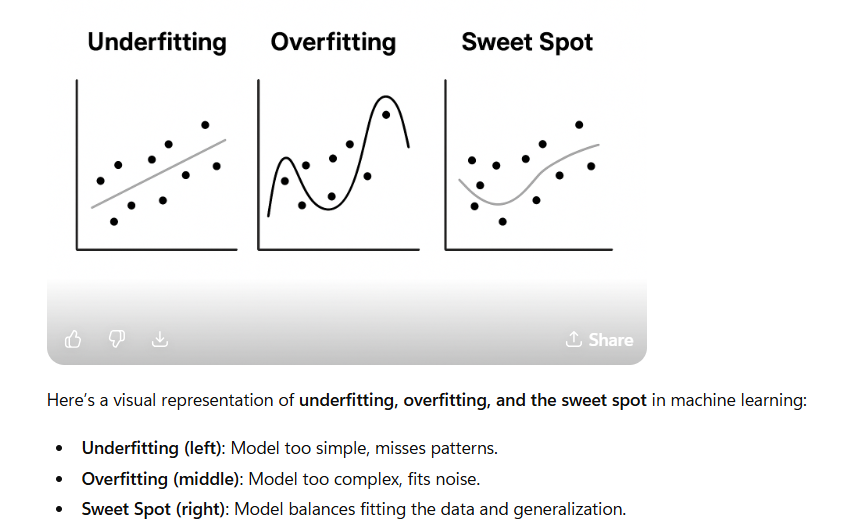